# Analisi repository di git con più stelle
Analisi delle repository più famose di git
Dipendenze:
- Matplotlib
- Pandas
- numpy

Utilizzare un venv

In [1]:
import pandas
import os

datasets = []

for domain in os.listdir("../data/domains"):
    datasets.append((domain.split(".")[0], pandas.read_csv(os.path.join("../data/domains", domain))))

print("Lista di dataset: " + str([x[0] for x in datasets]))

Lista di dataset: ['Machine Learning', 'Deep Learning', 'Python', 'JavaScript', 'Java', 'C++', 'Go', 'Rust', 'Data Science', 'Web Development', 'Android', 'iOS', 'Blockchain', 'Cybersecurity', 'DevOps']


Esempio di come è strutturato un dataset

In [2]:
datasets[0][1]

,Repository Name,Full Name,Description,Primary Language,Stars Count,Forks Count,Watchers Count,Open Issues Count,Has Wiki,Has Pages,Has Projects,Size (KB),Created At,Updated At,Pushed At,Default Branch,Owner Login,Owner Type,License,Topics
0,tensorflow,tensorflow/tensorflow,An Open Source Machine Learning Framework for ...,C++,194126,75247,194126,3715,False,False,True,1288956,2015-11-07T01:19:20Z,2026-03-14T00:28:29Z,2026-03-14T01:48:00Z,master,tensorflow,Organization,Apache License 2.0,"deep-learning, deep-neural-networks, distribut..."
1,transformers,huggingface/transformers,🤗 Transformers: the model-definition framework...,Python,157772,32464,157772,2282,True,False,True,453964,2018-10-29T13:56:00Z,2026-03-14T01:38:18Z,2026-03-13T23:15:04Z,main,huggingface,Organization,Apache License 2.0,"audio, deep-learning, deepseek, gemma, glm, ha..."
2,prompts.chat,f/prompts.chat,"f.k.a. Awesome ChatGPT Prompts. Share, discove...",HTML,152186,19999,152186,28,True,True,True,231182,2022-12-05T13:54:13Z,2026-03-14T02:08:32Z,2026-03-13T14:06:54Z,main,f,User,Creative Commons Zero v1.0 Universal,"ai, artificial-intelligence, awesome-list, cha..."
3,pytorch,pytorch/pytorch,Tensors and Dynamic neural networks in Python ...,Python,98216,27194,98216,18055,True,False,True,1273608,2016-08-13T05:26:41Z,2026-03-14T01:40:49Z,2026-03-14T02:08:49Z,main,pytorch,Organization,Other,"autograd, deep-learning, gpu, machine-learning..."
4,LLMs-from-scratch,rasbt/LLMs-from-scratch,Implement a ChatGPT-like LLM in PyTorch from s...,Jupyter Notebook,87955,13422,87955,1,False,False,False,15703,2023-07-23T18:15:57Z,2026-03-14T02:06:45Z,2026-03-07T23:05:50Z,main,rasbt,User,Other,"ai, artificial-intelligence, chatbot, chatgpt,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Machine-Learning,Jack-Cherish/Machine-Learning,:zap:机器学习实战（Python3）：kNN、决策树、贝叶斯、逻辑回归、SVM、线性回归...,Python,10250,5108,10250,7,False,False,False,1132,2017-03-25T07:32:37Z,2026-03-13T07:59:56Z,2024-07-12T11:28:35Z,master,Jack-Cherish,User,NaN,"adaboost, adaboost-algorithm, decision-tree, k..."
196,3D-Machine-Learning,timzhang642/3D-Machine-Learning,A resource repository for 3D machine learning,NaN,10144,1809,10144,20,True,False,True,24851,2017-08-12T15:20:54Z,2026-03-10T11:53:55Z,2024-07-04T19:13:09Z,master,timzhang642,User,NaN,"3d, 3d-reconstruction, constructive-solid-geom..."
197,autogluon,autogluon/autogluon,Fast and Accurate ML in 3 Lines of Code,Python,10094,1120,10094,392,False,False,True,25306,2019-07-29T18:51:24Z,2026-03-14T00:15:36Z,2026-03-10T19:01:20Z,master,autogluon,Organization,Apache License 2.0,"autogluon, automated-machine-learning, automl,..."
198,techniques,satellite-image-deep-learning/techniques,Techniques for deep learning with satellite & ...,NaN,10055,1637,10055,0,True,False,True,30166,2018-04-16T08:42:09Z,2026-03-13T05:38:12Z,2026-03-07T14:23:47Z,master,satellite-image-deep-learning,Organization,Apache License 2.0,"convolutional-neural-networks, dataset, datase..."


## Analisi del dataset

In [3]:
import matplotlib.pyplot as plt
import numpy as np

### Linguaggi più utilizzati per ogni ambito

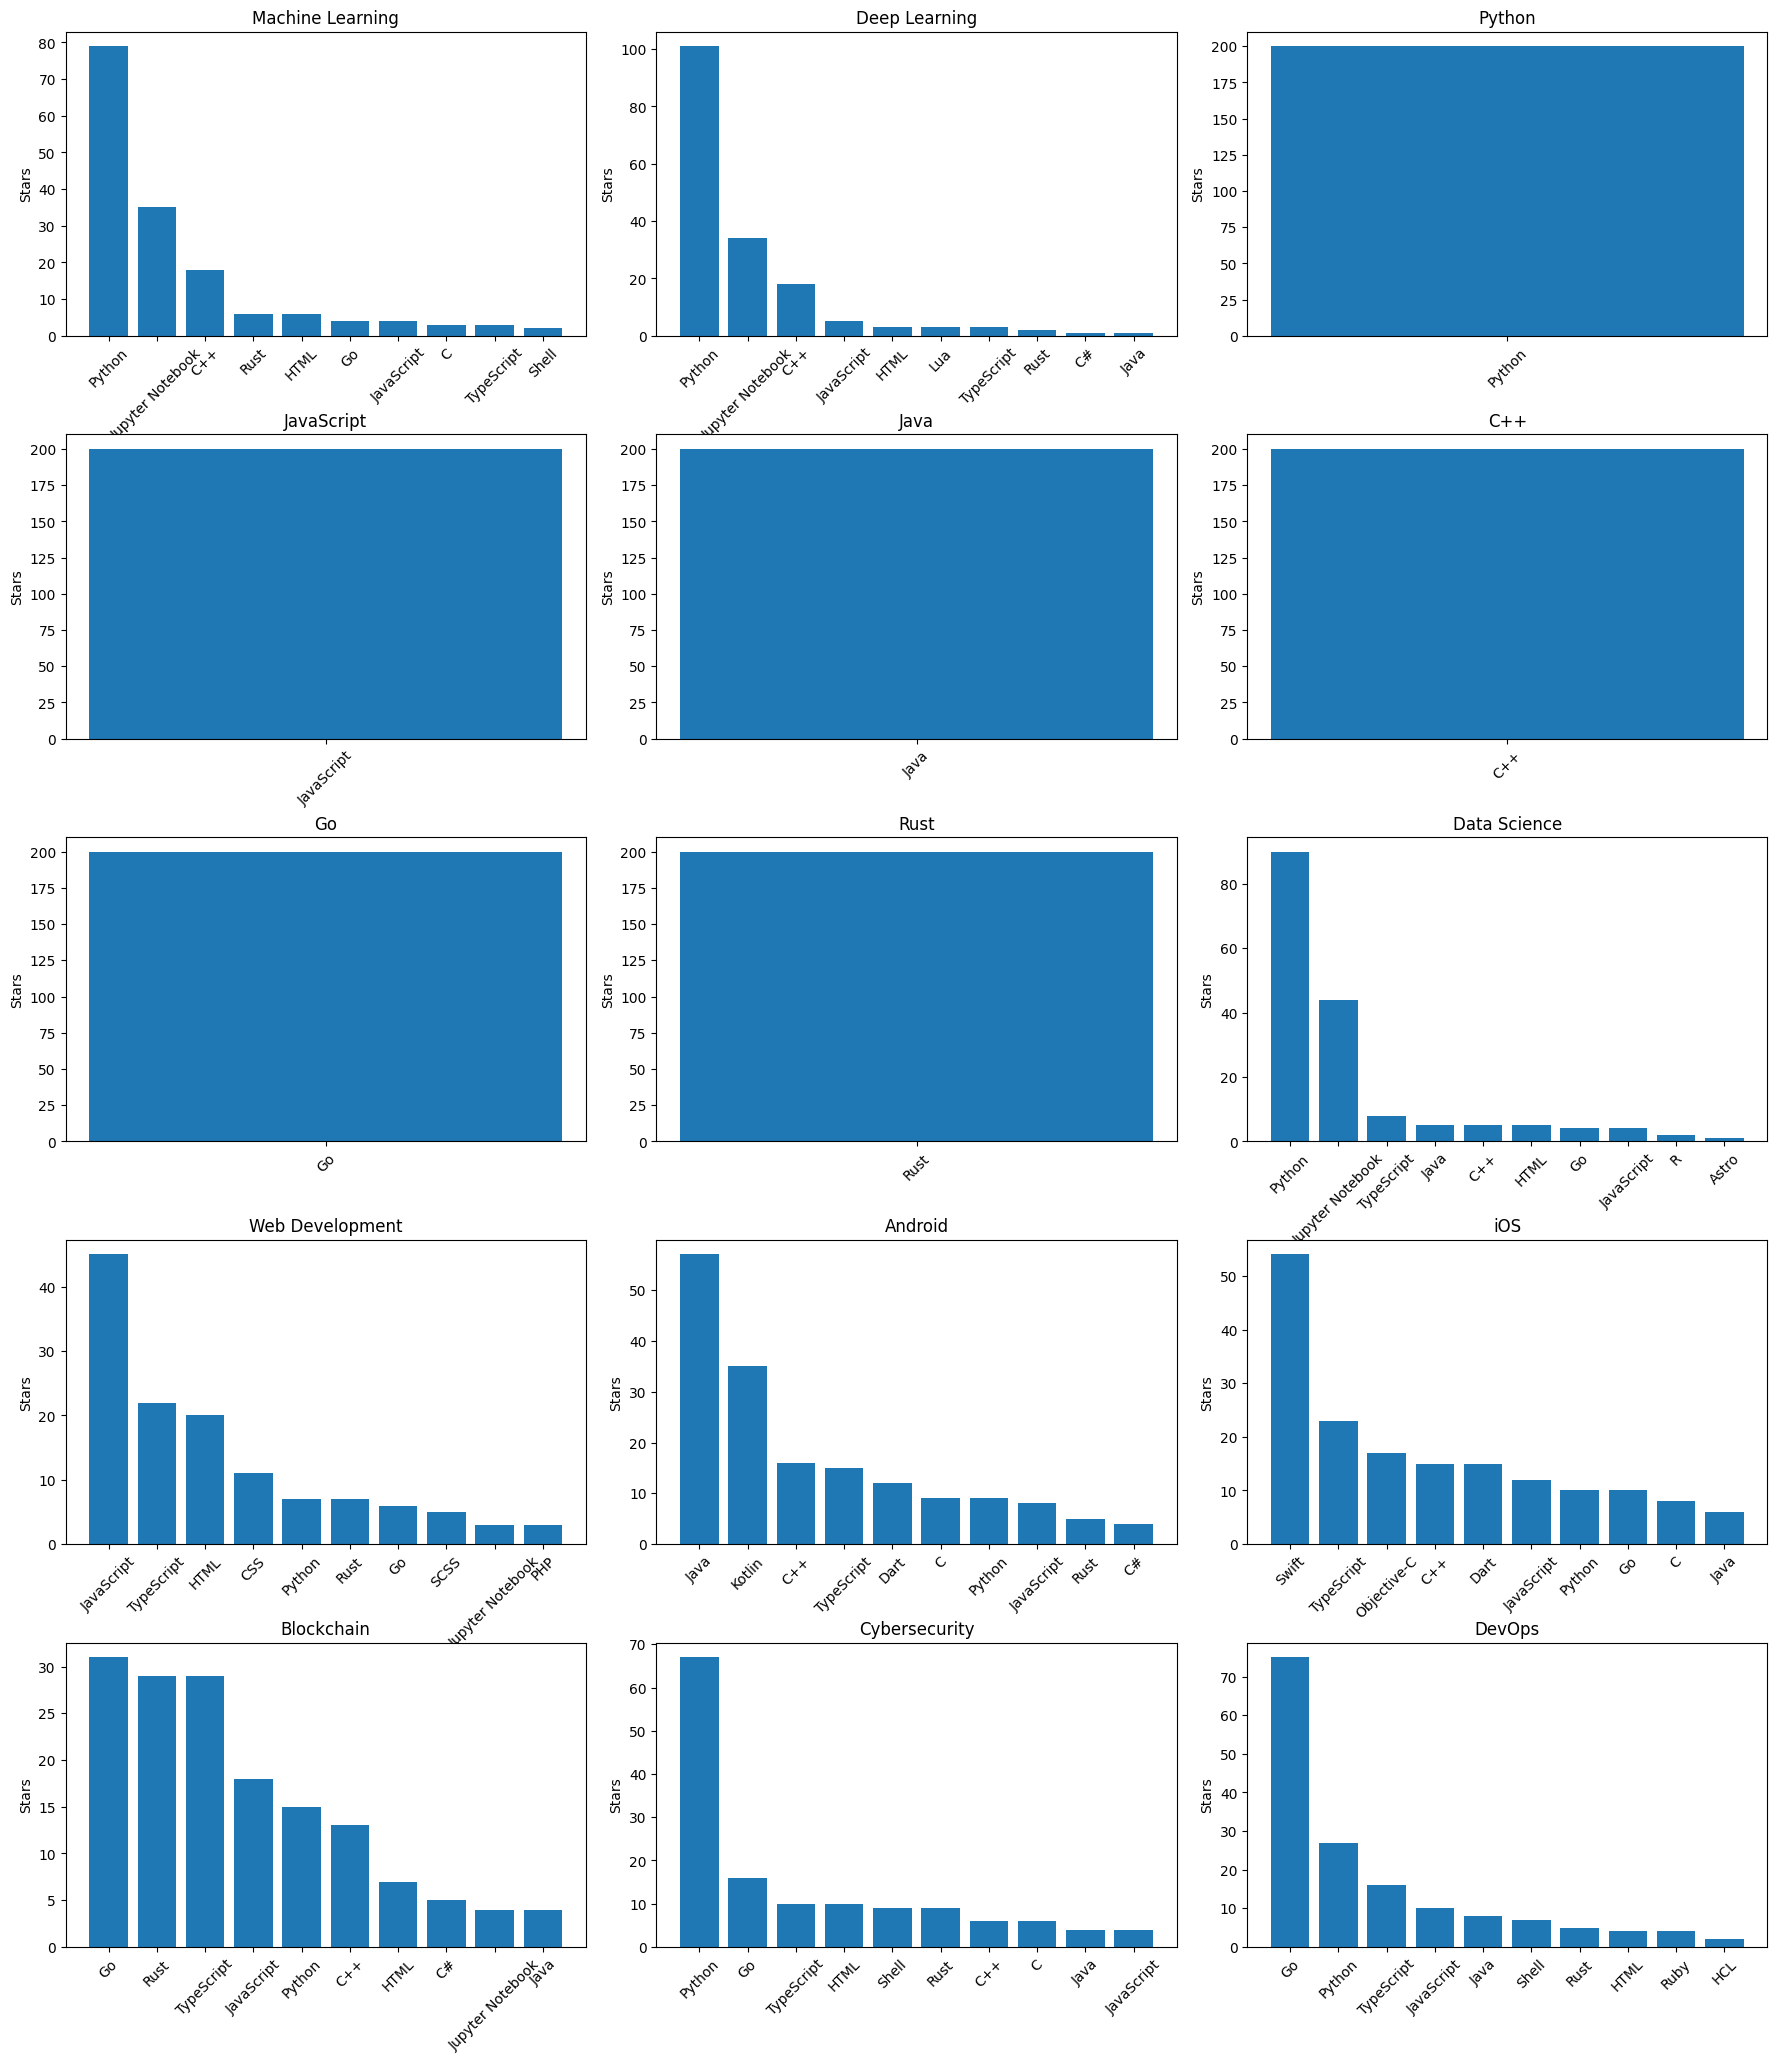

In [39]:
fig, ax = plt.subplots(int(len(datasets) / 3), 3, figsize=(18, 20))
plt.tight_layout(h_pad=5.0, pad=2)

for i, (domain, dataset) in enumerate(datasets):
    grouped = (
    dataset
    .dropna(subset=["Primary Language"])
    .groupby("Primary Language")
    .size()                      # 👈 counts repos
    .sort_values(ascending=False)
)

    grouped = grouped.head(10)  # top 10 languages
    row = i // 3
    col = i % 3

    ax[row, col].bar(grouped.index, grouped.values)

    ax[row, col].set_title(domain)
    ax[row, col].set_ylabel("Stars")
    ax[row, col].tick_params(axis='x', rotation=45)

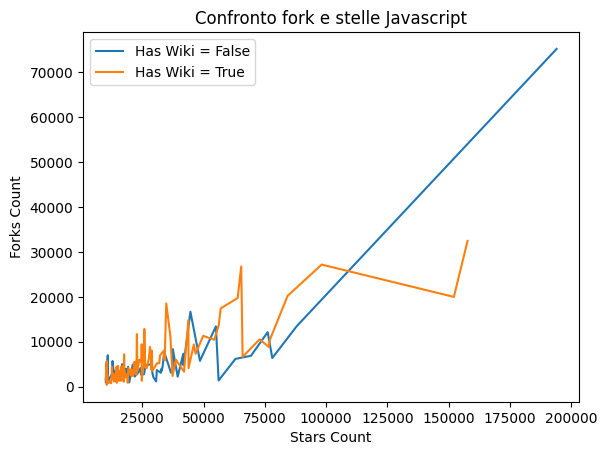

In [3]:
for has_wiki, group in datasets[0][1].groupby("Has Wiki"):
    group = group.sort_values("Stars Count")
    plt.plot(
        group["Stars Count"],
        group["Forks Count"],
        label=f"Has Wiki = {has_wiki}"
    )

plt.xlabel("Stars Count")
plt.ylabel("Forks Count")
plt.title("Confronto fork e stelle Javascript")
plt.legend()
plt.show()

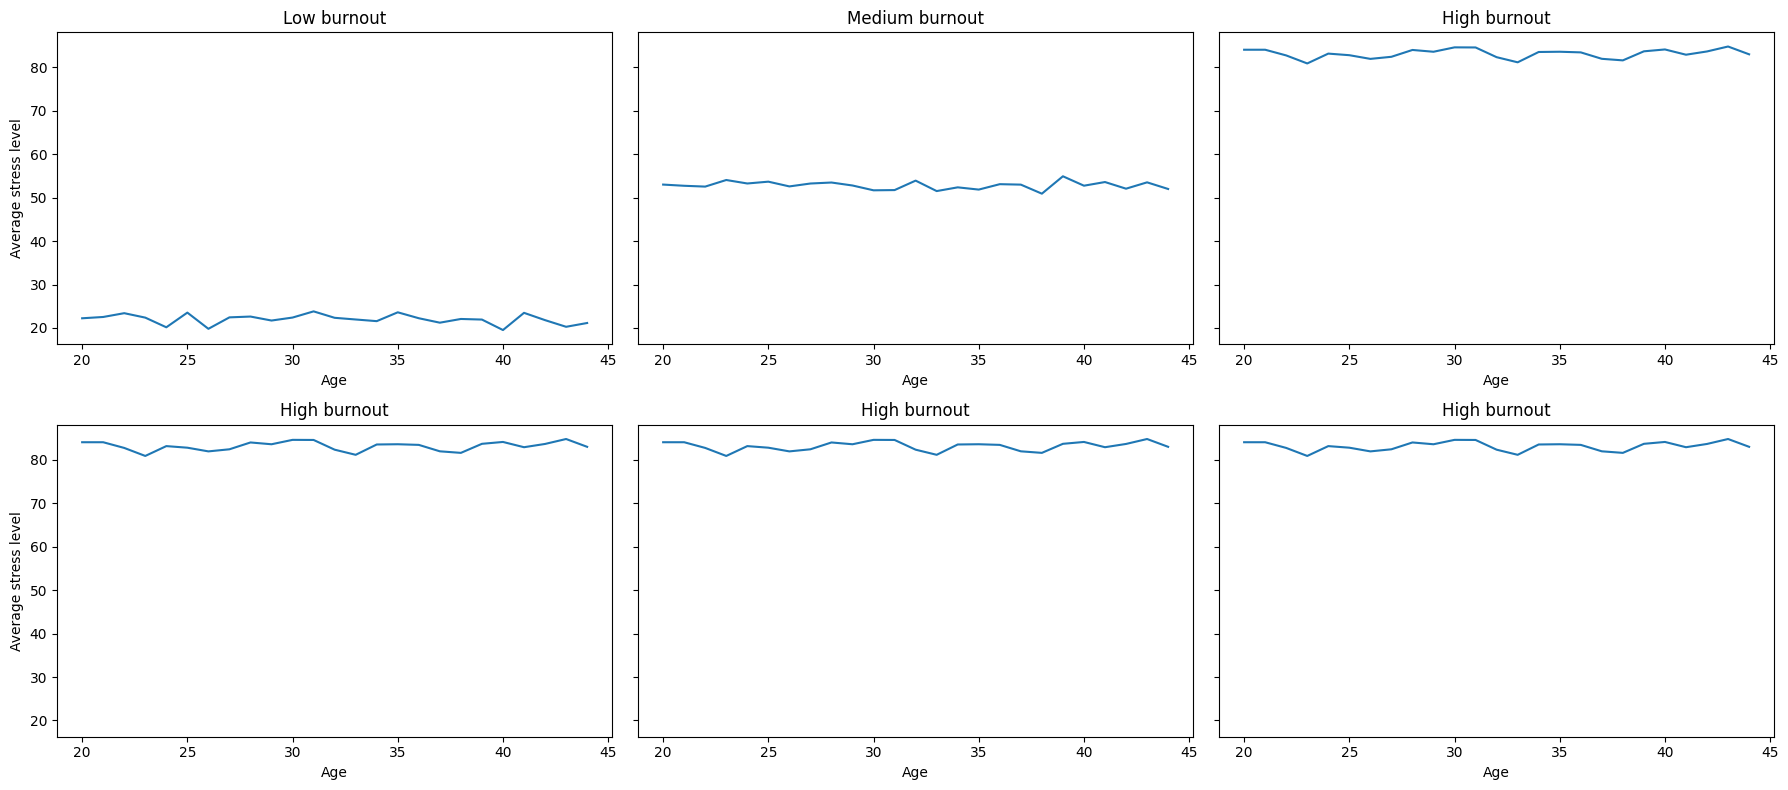

In [14]:
import matplotlib.pyplot as plt
import numpy as np

datasets = [low_burnout, medium_burnout, high_burnout, high_burnout, high_burnout , high_burnout]
titles = ["Low burnout", "Medium burnout", "High burnout",
          "High burnout", "High burnout", "High burnout"]

fig, ax = plt.subplots(2, 3, figsize=(18, 8), sharey=True)

for i, (df, title) in enumerate(zip(datasets, titles)):
    row = i // 3
    col = i % 3

    summary = df.groupby("age")["stress_level"].mean()

    ax[row, col].plot(summary.index, summary.values)
    ax[row, col].set_title(title)
    ax[row, col].set_xlabel("Age")

ax[0, 0].set_ylabel("Average stress level")
ax[1, 0].set_ylabel("Average stress level")

plt.tight_layout()
plt.show()

<Axes: xlabel='experience_years'>

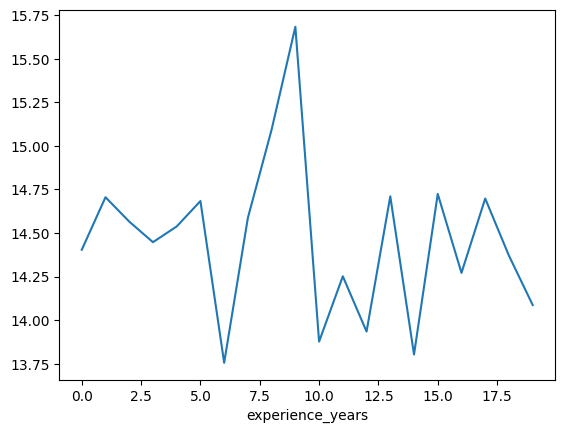

In [36]:
commits = dataset.groupby("experience_years")["commits_per_day"].mean()
commits.plot()

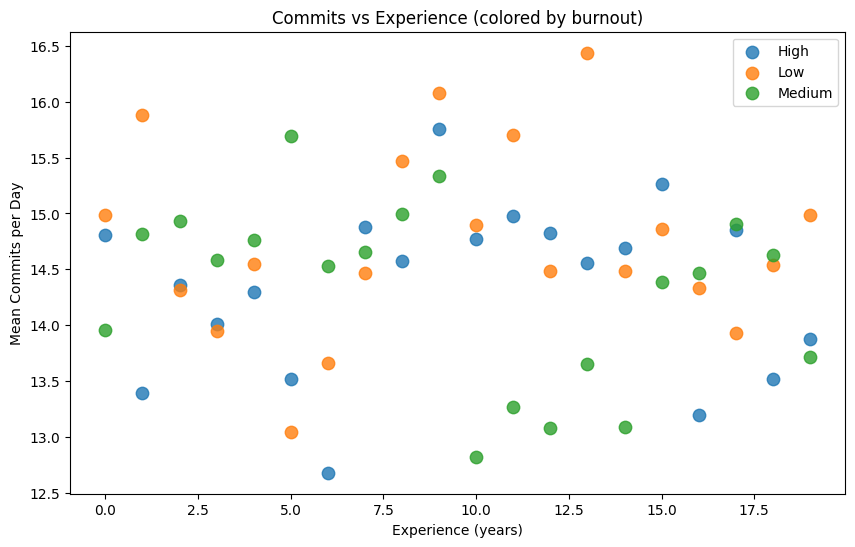

In [38]:
grouped = dataset.groupby(["experience_years", "burnout_level"])["commits_per_day"].mean().reset_index()
burnout_colors = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}
grouped["color"] = grouped["burnout_level"].map(burnout_colors)
plt.figure(figsize=(10, 6))

for burnout_level in grouped["burnout_level"].unique():
    subset = grouped[grouped["burnout_level"] == burnout_level]
    
    plt.scatter(
        subset["experience_years"],
        subset["commits_per_day"],
        label=burnout_level,
        alpha=0.8,
        s=80
    )

plt.xlabel("Experience (years)")
plt.ylabel("Mean Commits per Day")
plt.title("Commits vs Experience (colored by burnout)")
plt.legend()
plt.show()